<a href="https://colab.research.google.com/github/Ji2424/RL_Safety_Navigation/blob/main/RL_Safety_Navigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Safety-Constrained RL Navigation
### Anthropic Fellows Project — RL Workstream

**Goal:** Build a custom Gymnasium environment where an agent navigates a grid world to reach a goal, while being penalised for entering *safety-constrained zones*. I train a PPO agent and track both task performance (reward) and safety violations separately.

**Why this matters for AI Safety / RL research:**
A core challenge in deploying RL agents is ensuring they respect constraints (e.g. don't harm humans, don't exceed resource limits). This project is a minimal, clean environment to study that tension between reward maximisation and constraint satisfaction.

---
**Sections:**
1. Install & Imports
2. Build the Custom Gymnasium Environment
3. Sanity-check with a Random Agent
4. Train PPO Agent (Stable-Baselines3)
5. Evaluate & Visualise Results
6. Experiment: Tune the Safety Penalty


## Cell 1 — Install Dependencies

In [1]:
!pip install gymnasium stable-baselines3 matplotlib numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 1.6 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
print("All imports OK")

All imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 3 — Build the Custom Gymnasium Environment

**Grid layout (8x8):**
- 🟦 Agent starts at top-left (0,0)
- 🟩 Goal is at bottom-right (7,7)
- 🟥 Red zones = safety-constrained areas (agent is penalised for entering)
- ⬜ Free space

**Reward structure:**
| Event | Reward |
|---|---|
| Reach goal | +10.0 |
| Enter safety zone | -2.0 (configurable) |
| Each step | -0.1 (encourages efficiency) |
| Hit wall | -0.5 |

In [3]:
class SafetyGridEnv(gym.Env):
    """
    An 8x8 grid world where an agent must navigate from start to goal
    while avoiding safety-constrained zones.

    Observation: agent's (row, col) position — shape (2,)
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """

    metadata = {"render_modes": ["rgb_array"]}

    def __init__(self, grid_size=8, safety_penalty=2.0, max_steps=100):
        super().__init__()

        self.grid_size = grid_size
        self.safety_penalty = safety_penalty
        self.max_steps = max_steps

        # Start and goal positions
        self.start = np.array([0, 0])
        self.goal  = np.array([grid_size - 1, grid_size - 1])

        # Safety-constrained zones: list of (row, col) tuples
        self.safety_zones = {
            (1, 1), (1, 2), (1, 3),
            (2, 3), (3, 3), (3, 4),
            (4, 1), (4, 2),
            (5, 5), (5, 6),
            (6, 3), (6, 4), (6, 5),
        }

        # Gymnasium spaces
        self.observation_space = spaces.Box(
            low=0, high=grid_size - 1,
            shape=(2,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(4)  # Up, Down, Left, Right

        # Tracking
        self.agent_pos = self.start.copy()
        self.steps = 0
        self.violation_count = 0  # safety violations this episode

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start.copy().astype(np.float32)
        self.steps = 0
        self.violation_count = 0
        return self.agent_pos.copy(), {}

    def step(self, action):
        self.steps += 1
        reward = -0.1  # small step penalty
        info = {"safety_violation": False}

        # Movement deltas: Up, Down, Left, Right
        deltas = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        dr, dc = deltas[action]
        new_pos = self.agent_pos + np.array([dr, dc], dtype=np.float32)

        # Wall collision check
        if (0 <= new_pos[0] < self.grid_size and
                0 <= new_pos[1] < self.grid_size):
            self.agent_pos = new_pos
        else:
            reward -= 0.5  # wall penalty

        # Safety zone check
        pos_tuple = (int(self.agent_pos[0]), int(self.agent_pos[1]))
        if pos_tuple in self.safety_zones:
            reward -= self.safety_penalty
            self.violation_count += 1
            info["safety_violation"] = True

        # Goal check
        terminated = np.array_equal(self.agent_pos, self.goal)
        if terminated:
            reward += 10.0

        truncated = self.steps >= self.max_steps
        info["violation_count"] = self.violation_count

        return self.agent_pos.copy(), reward, terminated, truncated, info

    def render(self, mode="rgb_array"):
        """Returns an RGB array of the current grid state."""
        grid = np.zeros((self.grid_size, self.grid_size, 3), dtype=np.uint8)

        # White background
        grid[:, :] = [240, 240, 240]

        # Safety zones — red
        for (r, c) in self.safety_zones:
            grid[r, c] = [220, 60, 60]

        # Goal — green
        gr, gc = self.goal
        grid[int(gr), int(gc)] = [60, 180, 60]

        # Agent — blue
        ar, ac = self.agent_pos
        grid[int(ar), int(ac)] = [60, 100, 220]

        return grid


# Quick sanity check
env = SafetyGridEnv()
check_env(env, warn=True)
print("Environment passed Gymnasium check!")

Environment passed Gymnasium check!


## Cell 4 — Visualise the Grid Layout

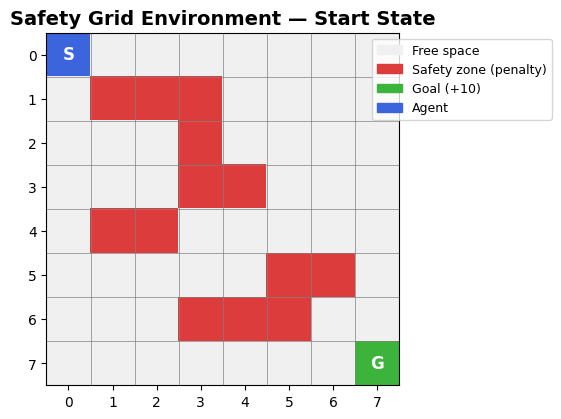

In [4]:
def visualise_grid(env, title="Grid Layout"):
    grid = np.zeros((env.grid_size, env.grid_size))

    for (r, c) in env.safety_zones:
        grid[r, c] = 1  # red zones

    gr, gc = env.goal
    grid[int(gr), int(gc)] = 2  # goal

    ar, ac = env.agent_pos
    grid[int(ar), int(ac)] = 3  # agent

    cmap = ListedColormap(["#F0F0F0", "#DC3C3C", "#3CB43C", "#3C64DC"])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3)

    # Grid lines
    for i in range(env.grid_size + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)

    # Labels
    ax.text(0, 0, 'S', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    ax.text(gc, gr, 'G', ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    legend_elements = [
        mpatches.Patch(color='#F0F0F0', label='Free space'),
        mpatches.Patch(color='#DC3C3C', label='Safety zone (penalty)'),
        mpatches.Patch(color='#3CB43C', label='Goal (+10)'),
        mpatches.Patch(color='#3C64DC', label='Agent'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              bbox_to_anchor=(1.45, 1), fontsize=9)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))
    plt.tight_layout()
    plt.show()

env.reset()
visualise_grid(env, title="Safety Grid Environment — Start State")

## Cell 5 — Baseline: Random Agent
Before training, see how a random agent performs. This is your baseline to beat.

In [5]:
def run_random_agent(n_episodes=200):
    env = SafetyGridEnv()
    total_rewards, violations, reached_goal = [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        ep_reward = 0
        done = False

        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            done = terminated or truncated

        total_rewards.append(ep_reward)
        violations.append(info["violation_count"])
        reached_goal.append(terminated)

    print("=== Random Agent Baseline ===")
    print(f"Mean episode reward : {np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
    print(f"Mean safety violations : {np.mean(violations):.2f} per episode")
    print(f"Goal reached : {np.mean(reached_goal)*100:.1f}% of episodes")
    return total_rewards, violations

random_rewards, random_violations = run_random_agent()

=== Random Agent Baseline ===
Mean episode reward : -55.28 ± 17.18
Mean safety violations : 20.64 per episode
Goal reached : 16.5% of episodes


## Cell 6 — Custom Callback to Track Violations During Training
This lets us log safety violations per episode alongside reward — critical for the research question.

In [6]:
class SafetyTrackingCallback(BaseCallback):
    """
    Logs episode rewards and safety violation counts during PPO training.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_violations = []
        self._current_reward = 0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]

        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            violations = self.locals["infos"][0].get("violation_count", 0)
            self.episode_violations.append(violations)
            self._current_reward = 0

        return True

print("Callback defined.")

Callback defined.


## Cell 7 — Train PPO Agent
PPO (Proximal Policy Optimisation) is a standard, well-understood RL algorithm — good choice for a clean research baseline.

In [7]:
SAFETY_PENALTY = 2.0   # <-- key hyperparameter you'll vary in experiments
TOTAL_TIMESTEPS = 150_000

train_env = SafetyGridEnv(safety_penalty=SAFETY_PENALTY)
callback = SafetyTrackingCallback()

model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=1
)

print(f"Training PPO with safety_penalty={SAFETY_PENALTY} for {TOTAL_TIMESTEPS:,} steps...")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
print("Training complete!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO with safety_penalty=2.0 for 150,000 steps...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 93.4     |
|    ep_rew_mean     | -51.4    |
| time/              |          |
|    fps             | 1825     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 93.5        |
|    ep_rew_mean          | -46.4       |
| time/                   |             |
|    fps                  | 1436        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011306003 |
|    clip_fraction        | 0.136       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.0207     |
|    learning_rate        | 0.

## Cell 8 — Plot Training Curves
Two plots: reward over time + safety violations over time. This is your core result figure.

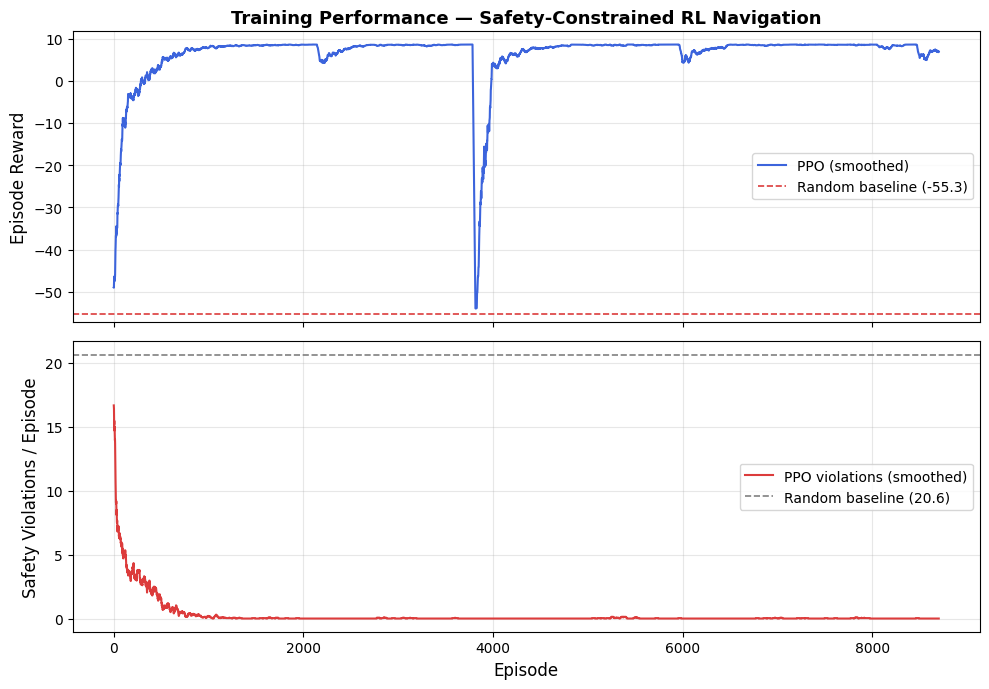

Saved: training_curves.png


In [8]:
def smooth(data, window=30):
    """Simple moving average for cleaner plots."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

rewards = callback.episode_rewards
violations = callback.episode_violations
episodes = range(len(smooth(rewards)))

# --- Reward plot ---
ax1.plot(smooth(rewards), color='#3C64DC', linewidth=1.5, label='PPO (smoothed)')
ax1.axhline(np.mean(random_rewards), color='#DC3C3C', linestyle='--',
            linewidth=1.2, label=f'Random baseline ({np.mean(random_rewards):.1f})')
ax1.set_ylabel('Episode Reward', fontsize=12)
ax1.set_title('Training Performance — Safety-Constrained RL Navigation', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# --- Violations plot ---
ax2.plot(smooth(violations), color='#DC3C3C', linewidth=1.5, label='PPO violations (smoothed)')
ax2.axhline(np.mean(random_violations), color='gray', linestyle='--',
            linewidth=1.2, label=f'Random baseline ({np.mean(random_violations):.1f})')
ax2.set_ylabel('Safety Violations / Episode', fontsize=12)
ax2.set_xlabel('Episode', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

## Cell 9 — Evaluate Trained Agent

In [9]:
def evaluate_agent(model, n_episodes=200):
    eval_env = SafetyGridEnv(safety_penalty=SAFETY_PENALTY)
    total_rewards, violations, reached_goal = [], [], []

    for _ in range(n_episodes):
        obs, _ = eval_env.reset()
        ep_reward = 0
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            ep_reward += reward
            done = terminated or truncated

        total_rewards.append(ep_reward)
        violations.append(info["violation_count"])
        reached_goal.append(terminated)

    print("=== PPO Trained Agent ===")
    print(f"Mean episode reward   : {np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
    print(f"Mean safety violations: {np.mean(violations):.2f} per episode")
    print(f"Goal reached          : {np.mean(reached_goal)*100:.1f}% of episodes")
    return total_rewards, violations

ppo_rewards, ppo_violations = evaluate_agent(model)

=== PPO Trained Agent ===
Mean episode reward   : 8.60 ± 0.00
Mean safety violations: 0.00 per episode
Goal reached          : 100.0% of episodes


## Cell 10 — Visualise a Trained Agent's Path

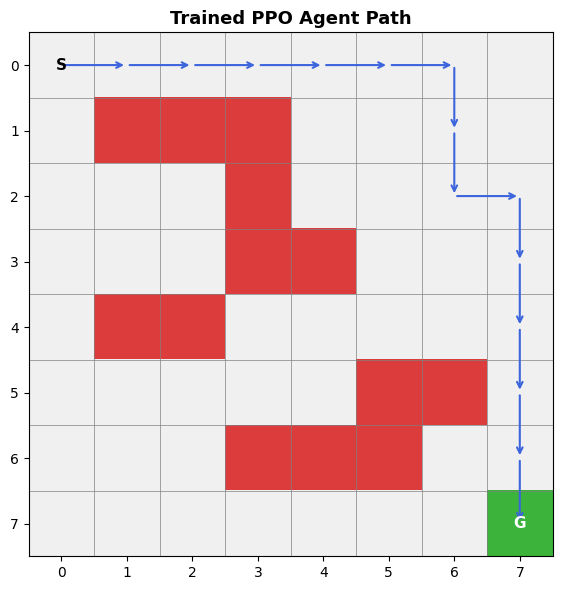

In [10]:
def visualise_agent_path(model, title="PPO Agent Path"):
    env = SafetyGridEnv(safety_penalty=SAFETY_PENALTY)
    obs, _ = env.reset()
    path = [tuple(env.agent_pos.astype(int))]
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        path.append(tuple(env.agent_pos.astype(int)))
        done = terminated or truncated

    # Draw grid
    grid = np.zeros((env.grid_size, env.grid_size))
    for (r, c) in env.safety_zones:
        grid[r, c] = 1
    gr, gc = env.goal
    grid[int(gr), int(gc)] = 2

    cmap = ListedColormap(["#F0F0F0", "#DC3C3C", "#3CB43C"])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)

    for i in range(env.grid_size + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)

    # Draw path
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i+1]
        ax.annotate("", xy=(c2, r2), xytext=(c1, r1),
                    arrowprops=dict(arrowstyle="->", color="#3C64DC", lw=1.5))

    ax.text(0, 0, 'S', ha='center', va='center', color='black', fontsize=11, fontweight='bold')
    ax.text(gc, gr, 'G', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))
    plt.tight_layout()
    plt.show()

visualise_agent_path(model, title="Trained PPO Agent Path")

## Cell 11 — Experiment: Vary the Safety Penalty

**This is your core research question:** How does the safety penalty magnitude affect the trade-off between task performance (reaching the goal) and constraint satisfaction (avoiding safety zones)?

This is directly relevant to AI safety research — it mirrors the challenge of tuning RLHF penalty coefficients in real LLM training.

In [11]:
penalties = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []

for penalty in penalties:
    print(f"\nTraining with safety_penalty={penalty}...")
    env_exp = SafetyGridEnv(safety_penalty=penalty)
    m = PPO("MlpPolicy", env_exp, learning_rate=3e-4, n_steps=2048,
            batch_size=64, n_epochs=10, gamma=0.99, verbose=0)
    m.learn(total_timesteps=100_000)

    # Evaluate
    eval_env = SafetyGridEnv(safety_penalty=penalty)
    ep_rewards, ep_violations, ep_goals = [], [], []
    for _ in range(100):
        obs, _ = eval_env.reset()
        ep_r, done = 0, False
        while not done:
            act, _ = m.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = eval_env.step(act)
            ep_r += r
            done = terminated or truncated
        ep_rewards.append(ep_r)
        ep_violations.append(info["violation_count"])
        ep_goals.append(terminated)

    results.append({
        "penalty": penalty,
        "mean_reward": np.mean(ep_rewards),
        "mean_violations": np.mean(ep_violations),
        "goal_rate": np.mean(ep_goals)
    })
    print(f"  Reward: {np.mean(ep_rewards):.2f} | Violations: {np.mean(ep_violations):.2f} | Goal rate: {np.mean(ep_goals)*100:.0f}%")

print("\nAll experiments done!")


Training with safety_penalty=0.0...
  Reward: 8.60 | Violations: 3.00 | Goal rate: 100%

Training with safety_penalty=0.5...
  Reward: 8.60 | Violations: 0.00 | Goal rate: 100%

Training with safety_penalty=1.0...
  Reward: 8.60 | Violations: 0.00 | Goal rate: 100%

Training with safety_penalty=2.0...
  Reward: -54.50 | Violations: 0.00 | Goal rate: 0%

Training with safety_penalty=5.0...
  Reward: -54.50 | Violations: 0.00 | Goal rate: 0%

Training with safety_penalty=10.0...
  Reward: -55.00 | Violations: 0.00 | Goal rate: 0%

All experiments done!


## Cell 12 — Plot the Safety-Performance Trade-off
This is your **key result figure** — the Pareto frontier between task performance and safety.

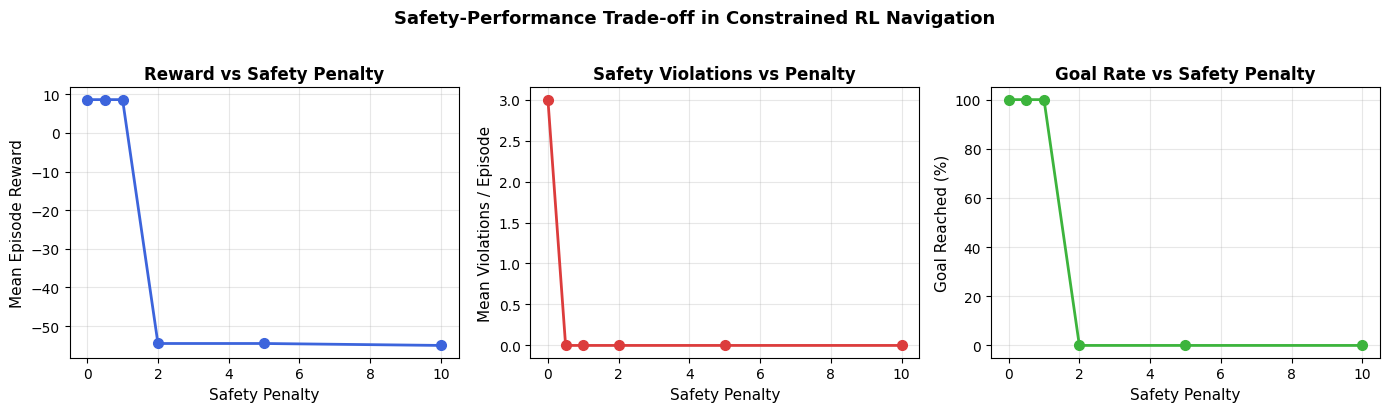

Saved: safety_tradeoff.png


In [12]:
penalties_plot  = [r["penalty"]         for r in results]
rewards_plot    = [r["mean_reward"]      for r in results]
violations_plot = [r["mean_violations"]  for r in results]
goal_rates      = [r["goal_rate"] * 100  for r in results]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(penalties_plot, rewards_plot, 'o-', color='#3C64DC', linewidth=2, markersize=7)
axes[0].set_xlabel('Safety Penalty', fontsize=11)
axes[0].set_ylabel('Mean Episode Reward', fontsize=11)
axes[0].set_title('Reward vs Safety Penalty', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(penalties_plot, violations_plot, 'o-', color='#DC3C3C', linewidth=2, markersize=7)
axes[1].set_xlabel('Safety Penalty', fontsize=11)
axes[1].set_ylabel('Mean Violations / Episode', fontsize=11)
axes[1].set_title('Safety Violations vs Penalty', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(penalties_plot, goal_rates, 'o-', color='#3CB43C', linewidth=2, markersize=7)
axes[2].set_xlabel('Safety Penalty', fontsize=11)
axes[2].set_ylabel('Goal Reached (%)', fontsize=11)
axes[2].set_title('Goal Rate vs Safety Penalty', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

fig.suptitle('Safety-Performance Trade-off in Constrained RL Navigation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('safety_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: safety_tradeoff.png")

## Next Steps & Extensions

Once this baseline works, here are meaningful extensions to make this more research-worthy:

1. **Constrained RL formulation** — separate constraint cost from reward, use Lagrangian methods (try `safety-gymnasium` or `CMDP` setups)
2. **Larger/randomised grids** — randomise safety zone placement each episode to test generalisation
3. **Compare algorithms** — PPO vs SAC vs a constrained RL baseline (e.g. CPO)
4. **Add partial observability** — agent only sees a local window (3x3) around itself, not the full grid
5. **Transfer experiment** — train on one safety zone layout, test on another

Any of these could form the basis of a short paper or technical report for your application.
